
# Colony matters: How density shapes predator access in two Antarctic fur seal (*Arctocephalus gazella*) colonies

**Authors:** Johannes Bartl, Ane Liv Berthelsen, Alexander Winterl, Cameron Fox-Clarke, Jaume Forcada, Rebecca Nagel, Joseph I. Hoffman, Ben Fabry

---

## Analysis Overview

This notebook details the data processing and statistical analysis workflow used to generate the results and figures presented in the manuscript.

### 1. Data Preparation & Filtering
The analysis begins with raw detection counts retrieved from the neural network. To ensure data quality and consistency, the following filters were applied prior to analysis:
* **Temporal Filtering:** Data is restricted to daylight hours (**09:00 – 17:00**) to ensure consistent visibility.
* **Image Quality Control:** A **Laplacian Variance** filter was applied to automatically exclude images compromised by environmental factors, such as heavy fog or water droplets on the lens.

### 2. Key Results & Figures
We perform the primary analyses described in the manuscript, corresponding to the following figures:

* **(a) Temporal trends in abundance at Special Study Beach**  (Figure 2)

* **(b) Abundance ratios of birds to pups between colonies** (Figure 3)

* **(c) Demographic patterns in seal density** (Figure 4)

* **(d) Spatial associations between birds and pups** (Figure 5)

In [1]:
# --- Standard Library ---
import glob
import math
import os
from pathlib import Path
from typing import List, Optional
from xml.dom.minidom import parse

# --- Third Party: Data & Math ---
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.spatial import Voronoi, QhullError
from scipy.stats import gaussian_kde
import torch
import yaml

# --- Third Party: Geospatial & Geometry ---
import cartopy.crs as ccrs
import contourpy
import geopandas as gpd
from shapely.geometry import GeometryCollection, MultiPolygon, Point, Polygon
from shapely.ops import unary_union

# --- Third Party: Image, Vision & AI ---
import cameratransform
from cameratransform import moveDistance
import clickpoints
from PIL import Image
from ultralytics import YOLO

# --- Third Party: Plotting & Visualization ---
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.dates as mpl_dates
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as patches
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch, Rectangle
from matplotlib.transforms import ScaledTranslation

# --- Utilities ---
from tqdm.auto import tqdm  # Automatically handles notebook/console bars

# --- Jupyter Magic ---
%matplotlib inline

### Helper functions

In [2]:
def kde_outline_from_hist2d_v2(x, y, prob=0.99, resolution=1.0, 
                                 sigma=1, padding=0.1, 
                                 return_shapely=False):

    x = np.asarray(x)
    y = np.asarray(y)
    
    # 0. Clean Data
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    
    if x.size == 0:
        return [], None if return_shapely else []

    # 1. Determine Data Extent
    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    
    # 2. Apply Padding to the Extent
    # We expand the bounds so the KDE doesn't get cut off at the exact data edge
    w = xmax - xmin
    h = ymax - ymin
    
    xmin -= padding * w
    xmax += padding * w
    ymin -= padding * h
    ymax += padding * h
    
    # 3. Calculate Number of Bins based on Resolution
    # Rule: Bin Count = Total Distance / Resolution
    # e.g., if Range is 20m and Resolution is 1m, we need 20 bins.
    x_range = xmax - xmin
    y_range = ymax - ymin
    
    n_bins_x = max(1, int(np.ceil(x_range / resolution)))
    n_bins_y = max(1, int(np.ceil(y_range / resolution)))
    
    # 4. Create the 2D Histogram (The Grid)
    # H represents the raw count of points in each grid cell
    H, xedges, yedges = np.histogram2d(x, y, bins=[n_bins_x, n_bins_y], 
                                       range=[[xmin, xmax], [ymin, ymax]])
    

    # 6. Apply Gaussian Smoothing
    Hs = gaussian_filter(H, sigma=sigma, mode='constant')
    
    vals = Hs.ravel()
    total = vals.sum()
    order = np.argsort(vals)[::-1]
    cum = np.cumsum(vals[order])

    k = np.searchsorted(cum, 0.99 * total)
    k = min(max(int(k), 0), vals.size - 1)
    thresh = float(vals[order][k])

    # guard against degenerate levels
    vmax = float(vals[order][0])
    eps = np.finfo(float).eps
    if thresh <= 0:
        thresh = max(vmax * 1e-12, eps)
    if thresh >= vmax:
        thresh = vmax - max(vmax * 1e-12, eps)

    # --- 2) grid coordinates (bin centers) ---
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])

    # histogram2d gives H shape (nx, ny), so transpose to (ny, nx)
    Z = Hs.T

    # --- 3) contour lines at that threshold ---
    cg = contourpy.contour_generator(x=xc, y=yc, z=Z, name="serial")
    lines = cg.lines(thresh)   # list of (N,2) arrays in (x,y)
    
    rings = [L for L in lines if len(L) >= 4 and np.allclose(L[0], L[-1])]
    mp = rings_to_multipolygon(rings)
    return H,Hs,lines,rings,mp

In [3]:
def rings_to_multipolygon(rings, close_tol=1e-9, fix_invalid=True):
    polys = []

    for r in rings:
        r = np.asarray(r)
        if r.shape[0] < 4:
            continue

        # ensure ring is closed
        if not np.allclose(r[0], r[-1], atol=close_tol, rtol=0):
            r = np.vstack([r, r[0]])

        p = Polygon(r)
        if p.is_empty or p.area <= 0:
            continue

        if fix_invalid and not p.is_valid:
            # common fix for self-intersections
            p = p.buffer(0)

        if not p.is_empty and p.area > 0:
            polys.append(p)

    if not polys:
        return MultiPolygon([])

    u = unary_union(polys)

    # keep polygonal parts only
    if isinstance(u, GeometryCollection):
        u = unary_union([g for g in u.geoms if g.geom_type in ("Polygon", "MultiPolygon")])

    # force MultiPolygon return
    if u.geom_type == "Polygon":
        return MultiPolygon([u])
    if u.geom_type == "MultiPolygon":
        return u

    return MultiPolygon([])

In [4]:
def plot_ge_dataset(ds, ax, elements=None):
    """
    ds = {"png": ..., "kml": ..., "cdb": ..., "name": ...}
    elements: list like ["rock", "water"]; if None -> all keys in COLORS
    """
    elements = list(elements) if elements is not None else list(COLORS.keys())

    img = plt.imread(ds["png"])
    marker, fov, polys = read_cdb_layers(ds["cdb"], wanted_layers=elements)

    # Fit pixel->lon/lat
    kml_corners = read_kml_corners(ds["kml"])
    marker[["lon", "lat"]] = kml_corners[["lon", "lat"]].to_numpy()
    pixel2ll = fit_pixel2lonlat(marker)

    # Extents
    extent_image = compute_image_extent(img, pixel2ll)
    extent = compute_fov_extent(fov.iloc[0], pixel2ll)

    # Draw
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.imshow(img, origin="upper", extent=extent_image, transform=ccrs.PlateCarree(), zorder=0)

    # Plot only requested-and-present layers
    for layer in elements:
        if layer in polys and layer in COLORS:
            plot_polygons(polys[layer], color=COLORS[layer], ax=ax, pixel2ll_func=pixel2ll, alpha=ALPHA)

In [5]:
def read_cdb_layers(cdb_path, wanted_layers):
    with clickpoints.DataFile(cdb_path) as cdb:
        marker = pd.DataFrame([[m.x, m.y, m.id] for m in cdb.getMarkers(type="marker")],
                              columns=["x","y","id"])
        fov = pd.DataFrame([[m.x, m.y, m.x+m.width, m.y+m.height, m.id]
                            for m in cdb.getRectangles(type="fov")],
                           columns=["x1","y1","x2","y2","id"])
        polys = {}
        for layer in wanted_layers:
            try:
                df = polygon_points_df(cdb, layer)
                if not df.empty:
                    polys[layer] = df
            except clickpoints.MarkerTypeDoesNotExist:
                # layer not present in this CDB -> skip
                continue
    return marker, fov, polys

def polygon_points_df(cdb, poly_type, id_col="poly_id"): 
    return pd.DataFrame(
        [(pid, x, y) for pid, poly in enumerate(cdb.getPolygons(type=poly_type), 1) for x, y in poly.points],
        columns=[id_col, "x", "y"]
    )
def read_kml_corners(kml_path):
    doc = parse(kml_path)
    # Take the first coordinates block (adjust if you need a specific placemark)
    coords_txt = doc.getElementsByTagName("coordinates")[0].firstChild.nodeValue.strip()
    pts = [tuple(map(float, c.split(",")[:2])) for c in coords_txt.split()]
    # Return as DataFrame with lon/lat in a known order
    df = pd.DataFrame(pts, columns=["lon", "lat"])
    return df

def fit_pixel2lonlat(marker):
    """
    Given a DataFrame `marker` with columns ['x','y','lon','lat'] for at least
    3 (but here 4) non-collinear control points, fit an affine map
       [lon, lat]^T = M · [x, y, 1]^T
    and return a function pixel2lonlat(x, y) -> (lon, lat).
    """
    # 1) Build design matrix A and target vectors
    pts_px     = marker[['x','y']].to_numpy()       # shape (4,2)
    pts_lonlat = marker[['lon','lat']].to_numpy()   # shape (4,2)
    A = np.hstack([pts_px, np.ones((pts_px.shape[0],1))])  # (4×3)

    # 2) Solve separately for lon and lat coefficients
    coeffs_lon = np.linalg.lstsq(A, pts_lonlat[:,0], rcond=None)[0]  # [a, b, c]
    coeffs_lat = np.linalg.lstsq(A, pts_lonlat[:,1], rcond=None)[0]  # [d, e, f]

    a, b, c = coeffs_lon
    d, e, f = coeffs_lat

    # 3) Return the mapping function
    def pixel2lonlat(x, y):
        """
        Map pixel coords x, y (scalar or array-like) to (lon, lat).
        """
        x = np.asarray(x)
        y = np.asarray(y)
        lon = a*x + b*y + c
        lat = d*x + e*y + f
        return lon, lat

    return pixel2lonlat

def plot_polygons(poly_df, color, ax, pixel2ll_func, zorder=2, alpha=0.5, edgecolor=None):
    """
    Plot polygons from a DataFrame with columns ['poly_id','x','y'] on a Cartopy axis.
    - poly_df: DataFrame of all polygon vertices
    - color: fill color for polygons
    - ax: Cartopy GeoAxes
    - pixel2ll_func: function mapping pixel x,y → lon,lat
    - zorder: drawing order
    - alpha: polygon transparency
    - edgecolor: border color
    """
    for pid, group in poly_df.groupby('poly_id'):
        # extract pixel coords
        xs = group['x'].values
        ys = group['y'].values
        # convert to lon/lat
        lons, lats = pixel2ll_func(xs, ys)
        # create a shapely polygon
        poly = Polygon(zip(lons, lats))
        # add to axis
        ax.add_geometries([poly], crs=ccrs.PlateCarree(),
                          facecolor=color, edgecolor=edgecolor,
                          alpha=alpha, zorder=zorder)
def compute_image_extent(img, pixel2ll):
    h, w = img.shape[:2]
    corners_px = np.array([[0,0], [w,0], [w,h], [0,h]])
    lons, lats = pixel2ll(corners_px[:,0], corners_px[:,1])
    return [lons.min(), lons.max(), lats.min(), lats.max()]

def compute_fov_extent(fov_row, pixel2ll):
    corners_fov_px = np.array([
        [fov_row["x1"], fov_row["y1"]],
        [fov_row["x1"], fov_row["y2"]],
        [fov_row["x2"], fov_row["y1"]],
        [fov_row["x2"], fov_row["y2"]],
    ])
    lons, lats = pixel2ll(corners_fov_px[:, 0], corners_fov_px[:, 1])
    return [lons.min(), lons.max(), lats.min(), lats.max()]
def add_scalebar(ax, length_m, label=None, location='lower left',
                 pad_frac=0.04, bar_frac=0.25, linewidth=3, color='k', text_kw=None):
    """
    Draw a horizontal scale bar of `length_m` meters on a Cartopy GeoAxes.
    - location: 'lower left' | 'lower right' | 'upper left' | 'upper right'
    - pad_frac: padding from the edges as a fraction of current extent
    - bar_frac: bar length as a fraction of axis width if label is too long; here we use meters directly
    """
    if text_kw is None:
        text_kw = dict(ha='center', va='top', fontsize=9, color=color)

    # Use the current geographic extent
    lonmin, lonmax, latmin, latmax = ax.get_extent(ccrs.PlateCarree())
    dlon_extent = lonmax - lonmin
    dlat_extent = latmax - latmin

    # Anchor point near the chosen corner
    xpad = pad_frac * dlon_extent
    ypad = pad_frac * dlat_extent

    if 'left' in location:
        x0 = lonmin + xpad
        ha_line = 1.0  # text center above mid
    else:
        x0 = lonmax - xpad
        ha_line = -1.0

    if 'lower' in location:
        y0 = latmin + ypad
        va_line = 1.0
        text_va = 'bottom'
    else:
        y0 = latmax - ypad
        va_line = -1.0
        text_va = 'top'

    # Convert desired meters to degrees of longitude at the anchor latitude
    m_per_deg = _meters_per_deg_lon(y0)
    dlon = (length_m / m_per_deg)

    # For right-side anchors, draw bar to the left
    if 'right' in location:
        x1 = x0 - dlon
    else:
        x1 = x0 + dlon

    # Draw the bar
    ax.plot([x0, x1], [y0, y0], transform=ccrs.PlateCarree(), color=color, linewidth=linewidth, solid_capstyle='butt',zorder=100)


    # Label
    if label is None:
        label = f"{int(length_m)} m" if length_m < 1000 else f"{int(round(length_m/1000))} km"
    ax.text((x0 + x1)/2, y0 + va_line*(0.02*dlat_extent),
            label, transform=ccrs.PlateCarree(),
            ha='center', va=text_va, **{k:v for k,v in text_kw.items() if k not in ('ha','va')},zorder=100)
    
def _meters_per_deg_lon(lat_deg):
    """Approx meters per degree of longitude at latitude (better than cos-approx)."""
    φ = np.deg2rad(lat_deg)
    # NOAA/NGA formula (WGS-84) for longitude length per degree
    return (111412.84*np.cos(φ) - 93.5*np.cos(3*φ) + 0.118*np.cos(5*φ))

def multipolygon_to_gps(cam, geom_xy, z_plane=0.0, fix_invalid=True):
    """
    Convert a shapely Polygon/MultiPolygon in camera-local XY (meters)
    into a shapely MultiPolygon in (lat, lon) by applying cam.gpsFromSpace.

    Returns: shapely MultiPolygon (may be empty)
    """
    if geom_xy is None or geom_xy.is_empty:
        return MultiPolygon([])

    if geom_xy.geom_type == "Polygon":
        polys = [geom_xy]
    elif geom_xy.geom_type == "MultiPolygon":
        polys = list(geom_xy.geoms)
    elif geom_xy.geom_type == "GeometryCollection":
        polys = [g for g in geom_xy.geoms if g.geom_type == "Polygon"]
    else:
        raise TypeError(f"Expected Polygon/MultiPolygon, got {geom_xy.geom_type}")

    out = []
    for p in polys:
        ext = _ring_xy_to_latlon(cam, p.exterior.coords, z_plane)
        if ext is None or ext.shape[0] < 4:
            continue

        holes = []
        for r in p.interiors:
            h = _ring_xy_to_latlon(cam, r.coords, z_plane)
            if h is not None and h.shape[0] >= 4:
                holes.append(h)

        q = Polygon(ext, holes=holes)

        if fix_invalid and (not q.is_valid):
            q = q.buffer(0)

        if not q.is_empty and q.area > 0:
            out.append(q)

    if not out:
        return MultiPolygon([])

    u = unary_union(out)

    if isinstance(u, GeometryCollection):
        u = unary_union([g for g in u.geoms if g.geom_type in ("Polygon", "MultiPolygon")])

    if u.is_empty:
        return MultiPolygon([])
    if u.geom_type == "Polygon":
        return MultiPolygon([u])
    if u.geom_type == "MultiPolygon":
        return u

    return MultiPolygon([])

def _ring_xy_to_latlon(cam, ring_coords, z_plane):
    """
    ring_coords: sequence of (x,y) from shapely (usually already closed)
    returns: Nx2 array of (lat, lon)
    """
    pts = np.asarray(ring_coords, dtype=float)
    if pts.ndim != 2 or pts.shape[0] < 4:
        return None

    P3 = np.column_stack([pts[:, 0], pts[:, 1], np.full(pts.shape[0], z_plane, dtype=float)])
    gps = np.asarray(cam.gpsFromSpace(P3), dtype=float)  # Nx3: lon, lat, alt
    latlon = gps[:, [1, 0]]  # <-- swap to (lat, lon)
    return latlon

def overlap_percent(a, b, mode="iou"):
    """
    a, b: shapely Polygon/MultiPolygon
    mode:
      - "iou"      : 100 * area(A∩B) / area(A∪B)        (Jaccard / IoU)
      - "of_a"     : 100 * area(A∩B) / area(A)          (how much of A is covered by B)
      - "of_b"     : 100 * area(A∩B) / area(B)          (how much of B is covered by A)
      - "min"      : 100 * area(A∩B) / min(area(A),area(B))
      - "max"      : 100 * area(A∩B) / max(area(A),area(B))
    """
    if a is None or b is None or a.is_empty or b.is_empty:
        return 0.0

    inter = a.intersection(b)
    inter_area = inter.area
    if inter_area <= 0:
        return 0.0

    area_a = a.area
    area_b = b.area

    if mode == "of_a":
        return 0.0 if area_a == 0 else 100.0 * inter_area / area_a
    if mode == "of_b":
        return 0.0 if area_b == 0 else 100.0 * inter_area / area_b
    if mode == "min":
        denom = min(area_a, area_b)
        return 0.0 if denom == 0 else 100.0 * inter_area / denom
    if mode == "max":
        denom = max(area_a, area_b)
        return 0.0 if denom == 0 else 100.0 * inter_area / denom

    # default: IoU
    union_area = a.union(b).area
    return 0.0 if union_area == 0 else 100.0 * inter_area / union_area

### Load data (get from Zenodo [DOI:10.5281/zenodo.18955385])

In [6]:
fwb = pd.read_csv("FWB.csv")
ssb = pd.read_csv("SSB.csv")

In [7]:
cam_ssb = cameratransform.load_camera("map/ssb_cam.ct")
cam_fwb = cameratransform.load_camera("map/fwb_cam.ct")

In [8]:
os.makedirs("figures",exist_ok=True)

### Setup: colors, labels, path

In [9]:
colors = {
    'female': '#1F77B4',
    'male': '#FF7F0E',
    'pup': '#2CA02C',
    'giant petrel': '#9467bd', 
    'skua': '#8C564B',
    'sheathbill': '#e377c2', 
    'fwb': 'salmon',
    'ssb': '#5254A3'
}
labels = {
    'male' : 'adult male',
    'female' : 'adult female',
    'pup' : 'pup',
    'giant petrel' : 'giant petrel',
    'sheathbill' : 'snowy sheathbill',
    'skua' : 'brown skua',
}

fontsize = 11

###  (a) Temporal trends in abundance at Special Study Beach

In [10]:
def daily_max_abundance(df, time_col="timestamp", class_col="class", group_col="filename"):
    # 1. extract date
    df['date'] = pd.to_datetime(df[time_col]).dt.date

    # 2. count detections per image (or per filename) per class per day
    counts = (
        df
        .groupby(['date', group_col, class_col])
        .size()
        .reset_index(name='count')
    )

    # 3. for each date & class, take the maximum count across images
    daily_max = (
        counts
        .groupby(['date', class_col])['count']
        .max()
        .unstack(fill_value=0)
    )
    return daily_max

In [11]:
ssb_abundance = daily_max_abundance(df=ssb)
fwb_abundance = daily_max_abundance(df=fwb)

In [12]:
first_born_pup_ssb = pd.Timestamp("2020-11-22")
first_born_pup_fwb = pd.Timestamp("2020-11-18")

In [13]:
# ssb_abundance_99 = daily_max_abundance(df=ssb_99)
# fwb_abundance_99 = daily_max_abundance(df=fwb_99)

#### SSB

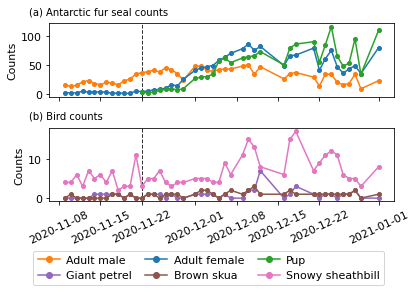

In [14]:
# Convert index to pandas Timestamp to prevent "Cannot compare Timestamp with date" error
ssb_abundance.index = pd.to_datetime(ssb_abundance.index)

# --- Plotting Setup ---
fig, axs = plt.subplots(figsize=(5.9, 4.1), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0.15)

groups = [
    ["male", "female", "pup"],
    ["giant petrel", "skua", "sheathbill"]
]
panel_titles = [
    "(a) Antarctic fur seal counts", 
    "(b) Bird counts"
]

# --- Main Plot Loop ---
for i, (ax, species_list) in enumerate(zip(axs, groups)):
    
    # Add vertical dashed line (zorder=0 puts it behind the lines)
    ax.axvline(first_born_pup_ssb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)

    for animal in species_list:
        x_data = ssb_abundance.index
        y_data = ssb_abundance[animal]
        
        # SPECIAL CASE: Filter Pups using the now compatible Timestamp
        if animal == 'pup':
            mask = x_data >= first_born_pup_ssb
            x_data = x_data[mask]
            y_data = y_data[mask]

        ax.plot(
            x_data, y_data,
            color=colors[animal], 
            marker='o', 
            markersize=4,
            label=labels[animal].capitalize()
        )

    # Styling
    ax.set_ylabel("Counts", fontsize=fontsize)
    
    # Panel Label
    trans = ax.transAxes + ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, panel_titles[i], transform=trans, fontsize='medium', va='bottom')

# --- Formatting ---
axs[0].tick_params(labelbottom=False)
axs[1].tick_params(axis='x', rotation=25, labelsize=fontsize)
axs[0].tick_params(axis='y', labelsize=fontsize)
axs[1].tick_params(axis='y', labelsize=fontsize)

# --- Legend ---
legend_order = ["male","giant petrel", "female", "skua", "pup", "sheathbill"]
handles = [Line2D([0], [0], marker='o', color=colors[a], linestyle='-') for a in legend_order]
labels_ = [labels[a].capitalize() for a in legend_order]

fig.legend(
    handles, labels_,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    fontsize=fontsize,
    columnspacing=1.2, 
    handletextpad=0.6, 
    borderaxespad=0.0,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("figures/figure2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

In [15]:
ssb_census = pd.read_excel("assets/census_ssb.xlsx",sheet_name="Summary 20_21",skiprows=7)

Unknown extension is not supported and will be removed


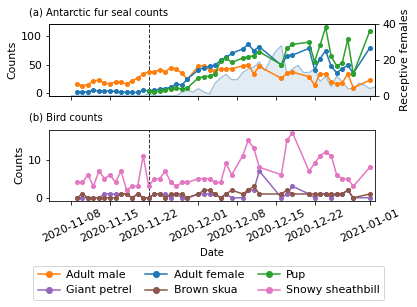

In [16]:
# Convert index to pandas Timestamp to prevent "Cannot compare Timestamp with date" error
ssb_abundance.index = pd.to_datetime(ssb_abundance.index)

# --- Plotting Setup ---
fig, axs = plt.subplots(figsize=(5.9, 4.3), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0.15)

groups = [
    ["male", "female", "pup"],
    ["giant petrel", "skua", "sheathbill"]
]
panel_titles = [
    "(a) Antarctic fur seal counts", 
    "(b) Bird counts"
]

# --- Main Plot Loop ---
for i, (ax, species_list) in enumerate(zip(axs, groups)):
    
    # Add vertical dashed line (zorder=0 puts it behind the lines)
    ax.axvline(first_born_pup_ssb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)

    for animal in species_list:
        x_data = ssb_abundance.index
        y_data = ssb_abundance[animal]
        
        # SPECIAL CASE: Filter Pups using the now compatible Timestamp
        if animal == 'pup':
            mask = x_data >= first_born_pup_ssb
            x_data = x_data[mask]
            y_data = y_data[mask]

        ax.plot(
            x_data, y_data,
            color=colors[animal], 
            marker='o', 
            markersize=4,
            label=labels[animal].capitalize()
        )

    # Styling
    ax.set_ylabel("Counts", fontsize=fontsize)
    
    # Panel Label
    trans = ax.transAxes + ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, panel_titles[i], transform=trans, fontsize='medium', va='bottom')

    
# --- Census twin axis on panel (a) ---
ax_census = axs[0].twinx()

census_dates = pd.to_datetime(ssb_census["Date"]) + pd.Timedelta(days=7)
census_vals  = ssb_census["New Females"]

ax_census.fill_between(census_dates, census_vals,
                        color='steelblue', alpha=0.15, zorder=0)
ax_census.plot(census_dates, census_vals,
               color='steelblue', lw=1.2, alpha=0.4, zorder=1)

ax_census.set_ylim(0, 40)
ax_census.set_ylabel("Receptive females", fontsize=fontsize, color='black')
ax_census.tick_params(axis='y', labelsize=fontsize, labelcolor='black')
ax_census.spines['right'].set_color('black')

# Make sure main axis stays on top visually
axs[0].set_zorder(ax_census.get_zorder() + 1)
axs[0].patch.set_visible(False)

axs[0].set_xlim(right=pd.Timestamp("2021-01-02"))
axs[1].set_xlim(right=pd.Timestamp("2021-01-02"))

# --- Formatting ---
axs[0].tick_params(labelbottom=False)
axs[1].tick_params(axis='x', rotation=25, labelsize=fontsize)
axs[0].tick_params(axis='y', labelsize=fontsize)
axs[1].tick_params(axis='y', labelsize=fontsize)

axs[1].set_xlabel("Date")

# --- Legend ---
legend_order = ["male","giant petrel", "female", "skua", "pup", "sheathbill"]
handles = [Line2D([0], [0], marker='o', color=colors[a], linestyle='-') for a in legend_order]
labels_ = [labels[a].capitalize() for a in legend_order]

fig.legend(
    handles, labels_,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    fontsize=fontsize,
    columnspacing=1.2, 
    handletextpad=0.6, 
    borderaxespad=0.0,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("figures/figure2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

#### FWB

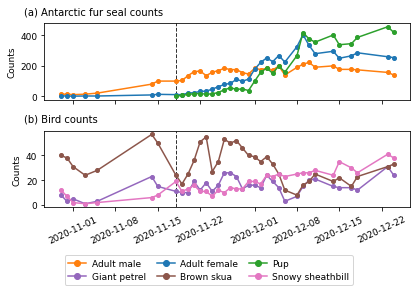

In [17]:

# Convert index to pandas Timestamp to prevent "Cannot compare Timestamp with date" error
fwb_abundance.index = pd.to_datetime(fwb_abundance.index)

# --- Plotting Setup ---
fontsize = 9
fig, axs = plt.subplots(figsize=(5.9, 4.1), nrows=2, sharex=True)
plt.subplots_adjust(hspace=0.15)

groups = [
    ["male", "female", "pup"],
    ["giant petrel", "skua", "sheathbill"]
]
panel_titles = [
    "(a) Antarctic fur seal counts", 
    "(b) Bird counts"
]

# --- Main Plot Loop ---
for i, (ax, species_list) in enumerate(zip(axs, groups)):
    
    # Add vertical dashed line (zorder=0 puts it behind the lines)
    ax.axvline(first_born_pup_fwb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)

    for animal in species_list:
        x_data = fwb_abundance.index
        y_data = fwb_abundance[animal]
        
        # SPECIAL CASE: Filter Pups using the now compatible Timestamp
        if animal == 'pup':
            mask = x_data >= first_born_pup_fwb
            x_data = x_data[mask]
            y_data = y_data[mask]

        ax.plot(
            x_data, y_data,
            color=colors[animal], 
            marker='o', 
            markersize=4,
            label=labels[animal].capitalize()
        )

    # Styling
    ax.set_ylabel("Counts", fontsize=fontsize)
    
    # Panel Label
    trans = ax.transAxes + ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, panel_titles[i], transform=trans, fontsize='medium', va='bottom')

# --- Formatting ---
axs[0].tick_params(labelbottom=False)
axs[1].tick_params(axis='x', rotation=25, labelsize=fontsize)
axs[0].tick_params(axis='y', labelsize=fontsize)
axs[1].tick_params(axis='y', labelsize=fontsize)

# --- Legend ---
legend_order = ["male","giant petrel", "female", "skua", "pup", "sheathbill"]
handles = [Line2D([0], [0], marker='o', color=colors[a], linestyle='-') for a in legend_order]
labels_ = [labels[a].capitalize() for a in legend_order]

fig.legend(
    handles, labels_,
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    fontsize=fontsize,
    columnspacing=1.2, 
    handletextpad=0.6, 
    borderaxespad=0.0,
    bbox_to_anchor=(0.5, 0.02)
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
# plt.savefig("figures/figure2.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

### (b) Abundance ratios of birds to pups between colonies


=== Giant petrel ===
  [FWB] Season-integrated ratio: 0.0920
  [SSB] Season-integrated ratio: 0.0198
  [FWB] Rolling ratio — median: 0.19, 95% CI: 0.04–1.15
  [SSB] Rolling ratio — median: 0.03, 95% CI: 0.01–0.19
  Mann-Whitney U: stat=687.0, p=0.0000 (***)

=== Brown skua ===
  [FWB] Season-integrated ratio: 0.1750
  [SSB] Season-integrated ratio: 0.0223
  [FWB] Rolling ratio — median: 0.44, 95% CI: 0.05–2.83
  [SSB] Rolling ratio — median: 0.03, 95% CI: 0.01–0.17
  Mann-Whitney U: stat=685.0, p=0.0000 (***)

=== Snowy sheathbill ===
  [FWB] Season-integrated ratio: 0.1152
  [SSB] Season-integrated ratio: 0.1480
  [FWB] Rolling ratio — median: 0.18, 95% CI: 0.08–1.12
  [SSB] Rolling ratio — median: 0.16, 95% CI: 0.10–1.24
  Mann-Whitney U: stat=369.0, p=0.8994 (ns)


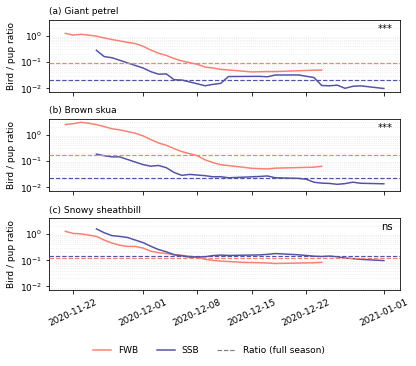

In [18]:
from matplotlib.lines import Line2D

bird_keys = ["giant petrel", "skua", "sheathbill"]
window = 7

ssb_abundance.index = pd.to_datetime(ssb_abundance.index)
fwb_abundance.index = pd.to_datetime(fwb_abundance.index)

mask_ssb = ssb_abundance.index > first_born_pup_ssb
mask_fwb = fwb_abundance.index > first_born_pup_fwb

ssb_s = ssb_abundance[mask_ssb]
fwb_s = fwb_abundance[mask_fwb]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5.9, 5), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.35)

for ax, species in zip(axes, bird_keys):
    display_name = labels[species].capitalize()
    rolling_data    = {}
    integrated_data = {}

    for beach, df_s, color in [
        ("FWB", fwb_s, colors['fwb']),
        ("SSB", ssb_s, colors['ssb']),
    ]:
        # Integrated ratio
        total_birds = df_s[species].sum()
        total_pups  = df_s['pup'].sum()
        integrated_data[beach] = total_birds / total_pups if total_pups > 0 else np.nan

        # Rolling ratio
        valid         = df_s['pup'] > 0
        rolling_birds = df_s[species][valid].rolling(window, min_periods=3).sum()
        rolling_pups  = df_s['pup'][valid].rolling(window, min_periods=3).sum()
        rolling_ratio = (rolling_birds / rolling_pups).dropna()
        rolling_data[beach] = rolling_ratio

        # Plot rolling ratio
        ax.plot(rolling_ratio.index, rolling_ratio.values,
                color=color, lw=1.5, label=beach)

        # Dashed seasonal ratio line
        ax.axhline(integrated_data[beach],
                   color=color, lw=1.2, linestyle='--', zorder=3)

       

    # --- Significance test on rolling ratios ---
    r_fwb = rolling_data.get('FWB', pd.Series(dtype=float))
    r_ssb = rolling_data.get('SSB', pd.Series(dtype=float))

    if len(r_fwb) > 0 and len(r_ssb) > 0:
        stat, p_val = stats.mannwhitneyu(r_fwb, r_ssb, alternative='two-sided')

        if p_val > 0.05:     sig = 'ns'
        elif p_val <= 0.001: sig = '***'
        elif p_val <= 0.01:  sig = '**'
        else:                sig = '*'

        y1     = integrated_data['FWB']
        y2     = integrated_data['SSB']
        y_low  = min(y1, y2)
        y_high = max(y1, y2)
        buf    = (y_high - y_low) * 0.15

#         x_bracket = 1.10
#         x_tick    = 1.12
#         trans     = ax.get_yaxis_transform()

#         # vertical ] bracket between the two seasonal ratios
#         ax.plot(
#             [x_bracket, x_tick, x_tick, x_bracket],
#             [y_low - buf, y_low - buf, y_high + buf, y_high + buf],
#             color='k', lw=1.2, transform=trans, clip_on=False
#         )

        # significance text in top right corner of each panel
        ax.text(
            0.98, 0.95, sig,
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10, color='k',
        )
            # --- Print statistics ---
        print(f"\n=== {display_name} ===")
        for beach, ratio in integrated_data.items():
            print(f"  [{beach}] Season-integrated ratio: {ratio:.4f}")
        for beach, r in rolling_data.items():
            med = r.median()
            ci_low  = r.quantile(0.025)
            ci_high = r.quantile(0.975)
            print(f"  [{beach}] Rolling ratio — median: {med:.2f}, 95% CI: {ci_low:.2f}–{ci_high:.2f}")
        if len(r_fwb) > 0 and len(r_ssb) > 0:
            print(f"  Mann-Whitney U: stat={stat:.1f}, p={p_val:.4f} ({sig})")

    # Formatting
    panel_label = chr(ord('a') + list(bird_keys).index(species))
    ax.set_title(f'({panel_label}) {display_name}', fontsize=fontsize, loc='left')
    ax.set_ylabel('Bird / pup ratio', fontsize=fontsize)
    ax.tick_params(axis='x', rotation=25, labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
#     ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.grid(axis='y', linestyle=':', alpha=0.2, which='minor', color='grey')
    ax.tick_params(axis='y', which='minor', left=False)
    ax.semilogy()
legend_handles = [
    Line2D([0], [0], color=colors['fwb'], lw=1.5, label='FWB'),
    Line2D([0], [0], color=colors['ssb'], lw=1.5, label='SSB'),
    Line2D([0], [0], color='grey', lw=1.2, linestyle='--',
           label='Ratio (full season)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=fontsize, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/figure3_timeseries_log.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

### (c) Demographic patterns in seal density

We determine the 99% outline of all females and pups to determine the area of the breeding colony.
Then we filter all seal detections based on that, as we are intersted in the density at the breeding site and want to exclude non-terriotal males

In [19]:
prob = 99
resolution = 1
sigma = 1


pts = ssb[ssb["class"].isin(["female","pup"])][["x_m","y_m"]].dropna().values
x, y = pts[:,0], pts[:,1]

_,_,_,_,mp_ssb = kde_outline_from_hist2d_v2(
        x, y,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

In [20]:
pts = fwb[fwb["class"].isin(["female","pup"])][["x_m","y_m"]].dropna().values
x, y = pts[:,0], pts[:,1]

_,_,_,_,mp_fwb = kde_outline_from_hist2d_v2(
        x, y,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

In [21]:
target_classes = ["male", "female", "pup"]
spatial_mask = [mp_ssb.contains(Point(x, y)) for x, y in tqdm(zip(ssb['x_m'], ssb['y_m']), total=len(ssb))]
cond_target_inside = (ssb["class"].isin(target_classes)) & (spatial_mask)
cond_other_classes = (~ssb["class"].isin(target_classes))
ssb_99 = ssb[cond_target_inside | cond_other_classes].copy()

  0%|          | 0/740111 [00:00<?, ?it/s]

In [22]:
spatial_mask = [mp_fwb.contains(Point(x, y)) for x, y in tqdm(zip(fwb['x_m'], fwb['y_m']), total=len(fwb))]
cond_target_inside = (fwb["class"].isin(target_classes)) & (spatial_mask)
cond_other_classes = (~fwb["class"].isin(target_classes))
fwb_99 = fwb[cond_target_inside | cond_other_classes].copy()

  0%|          | 0/4000032 [00:00<?, ?it/s]

In [23]:
fwb_99["class"].value_counts()/fwb.dropna()["class"].value_counts()

class
female          0.990950
giant petrel    1.000000
male            0.799973
pup             0.993746
sheathbill      1.000000
skua            1.000000
Name: count, dtype: float64

In [24]:
ssb_99["class"].value_counts()/ssb.dropna()["class"].value_counts()

class
female           0.994688
pup              0.994581
male             0.563784
penguin          1.013685
sheathbill       1.012110
elephant seal    1.033693
giant petrel     1.006211
skua             1.052209
Name: count, dtype: float64

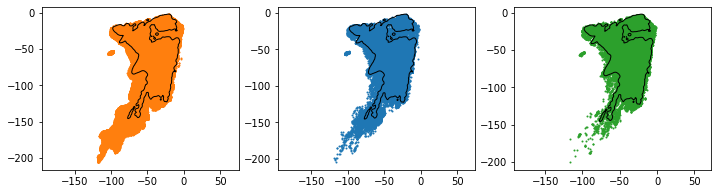

In [25]:
fig, ax = plt.subplots(figsize=(12,3),ncols=3)
for (a,c) in zip(ax,["male","female","pup"]):
    a.scatter(*fwb[fwb["class"].isin([c])][["x_m","y_m"]].values.T,s=1,color=colors[c])
    gpd.GeoSeries([mp_fwb]).plot(ax=a, 
                                 facecolor="none", 
                                 edgecolor="black", 
                                 linewidth=1)
    a.axis("equal")

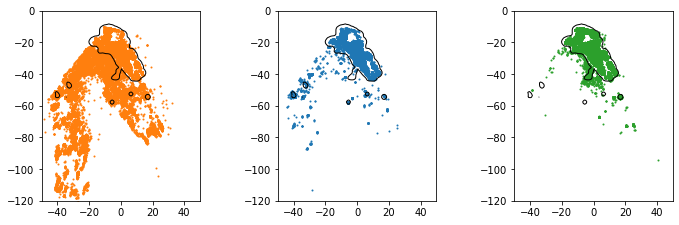

In [26]:
fig, ax = plt.subplots(figsize=(12,3.5),ncols=3)
for (a,c) in zip(ax,["male","female","pup"]):
    a.scatter(*ssb[ssb["class"].isin([c])][["x_m","y_m"]].values.T,s=1,color=colors[c])
    gpd.GeoSeries([mp_ssb]).plot(ax=a, 
                                 facecolor="none", 
                                 edgecolor="black", 
                                 linewidth=1)
    a.set_xlim(-50,50)
    a.set_ylim(-120,0)
#     a.axis("equal")
    

In [27]:
COLORS = {
    "background": "#A0A0A0",
    "water":      "#AAD3DF",
    "rocks":       "#A0A0A0",
    "vegetation": "#CDEBB0",
    "beach":      "#E6DCD2",
    "passway":    "#F2EFE9",
    "stream": "#AAD3DF",
    "building": "#F2EFE9",
    "jetty": "#F2EFE9"
}


In [28]:
cdb_path = "./20201112-144100_microbsBI_X141208110665_seals_SSB.cdb"
ct_path = "./X141208110665_20201112-144100_20201112-144500.ct"

In [29]:
import cameratransform as ct
import clickpoints
import numpy as np
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import unary_union

# --- 1. Load camera ---
cam = ct.load_camera(ct_path)

# --- 2. Load passway polygons from cdb and project to space ---
polys_space = []

with clickpoints.DataFile(cdb_path, "r") as db:
    for poly in db.getPolygons(type="passway"):
        pts_px = np.array(poly.points)  # (N, 2) in pixel coords [x, y]
        
        # Project pixel → space (x_m, y_m, z_m) assuming Z=0 ground plane
        pts_space = cam.spaceFromImage(pts_px, Z=0)  # (N, 3)
        
        # Drop any NaN rows (points behind camera / outside FOV)
        valid = ~np.isnan(pts_space).any(axis=1)
        pts_space = pts_space[valid]
        
        if len(pts_space) >= 3:
            polys_space.append(Polygon(pts_space[:, :2]))  # use x_m, y_m only

# --- 3. Combine into a single MultiPolygon ---


passway_mp = unary_union(polys_space)

print(f"Found {len(polys_space)} passway polygon(s)")
print(f"Total area: {passway_mp.area:.1f} m²")

Found 7 passway polygon(s)
Total area: 130.7 m²


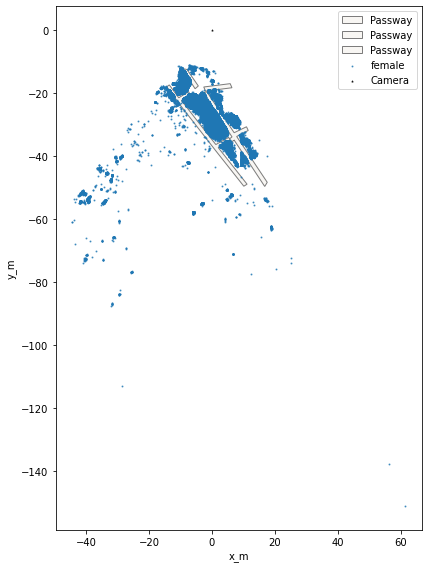

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

fig, ax = plt.subplots(figsize=(8, 8))

# Draw passway
for geom in passway_mp.geoms:
    pts = np.array(geom.exterior.coords)
    ax.add_patch(MplPolygon(pts, closed=True,
                            facecolor=COLORS["passway"], edgecolor="k",
                            alpha=0.5, label="Passway"))

# Females
animal = "female"
animals = ssb[ssb["class"] == animal]
ax.scatter(animals["x_m"], animals["y_m"],
           c=colors[animal], s=1, alpha=0.7, zorder=5, label=animal)

ax.scatter(0, 0, c="k", s=1, marker="^", zorder=6, label="Camera")
ax.set_aspect("equal")
ax.autoscale()
ax.set_xlabel("x_m"); ax.set_ylabel("y_m")
ax.legend()
plt.tight_layout()
plt.show()


In [33]:
def add_voronoi_areas(
    df: pd.DataFrame,
    classes: List[str],
    x_col: str = "x_m",
    y_col: str = "y_m",
    time_col: str = "timestamp",
    class_col: str = "class",
    occluder: MultiPolygon = None,
    occluder_classes: List[str] = None,
) -> pd.DataFrame:
    """
    Computes Voronoi areas per animal per timestamp.
    Optionally masks cells intersecting `occluder`, but only for `occluder_classes`.
    """
    df2 = df[df[class_col].isin(classes)].copy()
    if occluder is not None and not occluder.is_empty:
        occluder = occluder.buffer(0)

    tqdm.pandas()

    def _group_areas(group: pd.DataFrame) -> pd.DataFrame:
        pts = group[[x_col, y_col]].values
        if len(pts) < 3:
            return group.assign(voronoi_area=np.nan)

        try:
            vor = Voronoi(pts)
        except QhullError:
            return group.assign(voronoi_area=np.nan)

        areas = []
        for pt_idx, region_idx in enumerate(vor.point_region):
            verts = vor.regions[region_idx]
            if not verts or -1 in verts:
                areas.append(np.nan)
                continue

            cell_poly = Polygon(vor.vertices[verts])

            if (
                occluder is not None
                and occluder_classes is not None
                and group.iloc[pt_idx][class_col] in occluder_classes
                and cell_poly.intersects(occluder)
            ):
                areas.append(np.nan)
            else:
                areas.append(cell_poly.area)

        return group.assign(voronoi_area=areas)

    return (
        df2
        .groupby(time_col, group_keys=False)
        .progress_apply(_group_areas)
        .reset_index(drop=True)
    )

In [34]:
cases = [["male"], ["female"], ["pup"], ["male", "female", "pup"]]

# Raw (no occlusion)
vor_cache = {}
for case in cases:
    vor_cache[("ssb", tuple(case))] = add_voronoi_areas(ssb_99.dropna(), classes=case)
    vor_cache[("fwb", tuple(case))] = add_voronoi_areas(fwb_99.dropna(), classes=case)

# Occluder-corrected
vor_cache_occ = {}
for case in cases:
    occ_classes = [c for c in case if c in ["female", "pup"]]
    vor_cache_occ[("ssb", tuple(case))] = add_voronoi_areas(
        ssb_99.dropna(), classes=case,
        occluder=passway_mp,
        occluder_classes=occ_classes or None,
    )
    vor_cache_occ[("fwb", tuple(case))] = add_voronoi_areas(
        fwb_99.dropna(), classes=case,
        occluder=None,
    )

  0%|          | 0/9734 [00:00<?, ?it/s]

  0%|          | 0/10046 [00:00<?, ?it/s]

  0%|          | 0/7879 [00:00<?, ?it/s]

  0%|          | 0/9712 [00:00<?, ?it/s]

  0%|          | 0/6319 [00:00<?, ?it/s]

...

  0%|          | 0/9712 [00:00<?, ?it/s]

  0%|          | 0/6319 [00:00<?, ?it/s]

  0%|          | 0/9008 [00:00<?, ?it/s]

  0%|          | 0/9781 [00:00<?, ?it/s]

  0%|          | 0/10046 [00:00<?, ?it/s]

['male'] 985256 107782
Case ['male']: FWB Peak=2.27e-02, SSB Peak=4.40e-02, Ratio=1.94
['female'] 1196069 235561
Case ['female']: FWB Peak=1.24e-01, SSB Peak=6.95e-01, Ratio=5.62
['pup'] 1219348 222456
Case ['pup']: FWB Peak=1.24e-01, SSB Peak=5.03e-01, Ratio=4.07
['male', 'female', 'pup'] 3400673 565799
Case ['male', 'female', 'pup']: FWB Peak=2.73e-01, SSB Peak=1.13e+00, Ratio=4.14


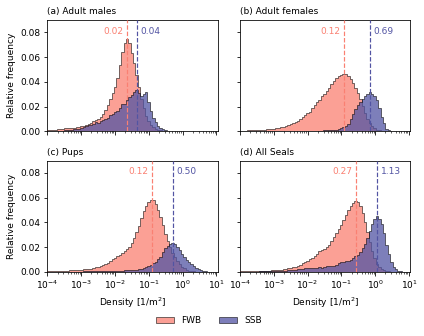

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde 

fontsize = 9
bins = np.logspace(np.log10(1e-5), np.log10(1e2), 100)
titles = ["(a) Adult males", "(b) Adult females", "(c) Pups", "(d) All Seals"]

# --- Simple In-Memory Cache ---
# This ensures we don't overwrite the cache if you re-run this specific cell
if 'kde_peaks_cache' not in globals():
    kde_peaks_cache = {}
# ------------------------------

fig, axes = plt.subplots(2, 2, figsize=(5.9, 4.5), sharey=True, sharex=True)
axes = axes.flatten()

for i, (ax, case) in enumerate(zip(axes, cases)):
    ssb_vor = vor_cache_occ[("ssb", tuple(case))]
    fwb_vor = vor_cache_occ[("fwb", tuple(case))]
    ssb_vals = 1 / ssb_vor.loc[ssb_vor['class'].isin(case), 'voronoi_area']
    fwb_vals = 1 / fwb_vor.loc[fwb_vor['class'].isin(case), 'voronoi_area']

    weights_fwb = np.ones_like(fwb_vals) / len(fwb_vals)
    ax.hist(fwb_vals, bins=bins, weights=weights_fwb,
            label='FWB', color=colors["fwb"], edgecolor="black",
            histtype='stepfilled', zorder=9, lw=0.7, alpha=0.75)

    weights_ssb = np.ones_like(ssb_vals) / len(ssb_vals)
    ax.hist(ssb_vals, bins=bins, weights=weights_ssb,
            label='SSB', color=colors["ssb"], edgecolor="black",
            histtype='stepfilled', zorder=10, lw=0.7, alpha=0.75)
    
    print(case,len(fwb_vals),len(ssb_vals))

    peak_locs = {}

    for label, vals, color in [("FWB", fwb_vals, colors["fwb"]), ("SSB", ssb_vals, colors["ssb"])]:
        if len(vals) > 1:
            
            # Create a unique key for this specific case and beach
            cache_key = (tuple(case), label)
            
            # --- Check Dict or Calculate ---
            if cache_key in kde_peaks_cache:
                true_peak = kde_peaks_cache[cache_key]
            else:
                log_vals = np.log10(vals[vals > 0])
                kde = gaussian_kde(log_vals)
                grid_log = np.linspace(np.log10(1e-5), np.log10(1e2), 1000)
                kde_y = kde(grid_log)
                peak_log = grid_log[np.argmax(kde_y)]
                true_peak = 10**peak_log
                
                # Save to our memory dictionary
                kde_peaks_cache[cache_key] = true_peak
            # -------------------------------

            peak_locs[label] = true_peak
            ax.axvline(true_peak, color=color, linestyle='--', linewidth=1.2, zorder=15)
            
            # --- Add peak value text ---
            if label == "SSB":  
                ha = 'left'
                xytext = (4, 0) 
            else:               
                ha = 'right'
                xytext = (-4, 0)  

            ax.annotate(f"{true_peak:.2f}",
                        xy=(true_peak, 0.9), 
                        xycoords=ax.get_xaxis_transform(), 
                        xytext=xytext,
                        textcoords='offset points',
                        ha=ha,
                        va='center',
                        color=color,
                        fontsize=9,
                        zorder=20)

    if "FWB" in peak_locs and "SSB" in peak_locs:
        ratio = peak_locs["SSB"] / peak_locs["FWB"]
        print(f"Case {case}: FWB Peak={peak_locs['FWB']:.2e}, SSB Peak={peak_locs['SSB']:.2e}, Ratio={ratio:.2f}")

    ax.set_xscale('log')
    ax.set_title(titles[i], fontsize=fontsize, loc="left")
    ax.tick_params(axis="both", labelsize=fontsize)
    ax.set_ylim(0, 0.09)
    ax.set_xlim(1e-4, 1.1e1)

    if i >= 2:
        ax.set_xlabel(r"Density [$\mathrm{1/m^2}$]", fontsize=9)

    if i % 2 == 0:
        ax.set_ylabel("Relative frequency", fontsize=9)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=2,
           frameon=False,
           fontsize=fontsize)

plt.tight_layout()
plt.savefig("figures/SIfigure5.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

In [36]:
kde_peaks_cache = {}

Case ['female']: FWB Peak=1.24e-01, SSB Peak=6.11e-01, Ratio=4.94
Case ['pup']: FWB Peak=1.24e-01, SSB Peak=2.47e-01, Ratio=2.00
Case ['male', 'female', 'pup']: FWB Peak=2.73e-01, SSB Peak=1.07e+00, Ratio=3.94


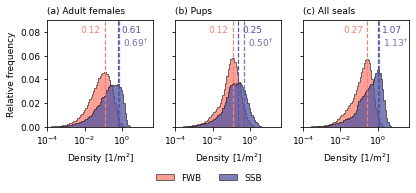

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde 

corrected_peaks = {
    ("female", "SSB"): 0.69,
    ("pup",    "SSB"): 0.50,
    ("all",    "SSB"): 1.13,
}
case_key_map = {
    tuple(["female"]):                   "female",
    tuple(["pup"]):                      "pup",
    tuple(["male", "female", "pup"]):    "all",
}

fontsize = 9
bins = np.logspace(np.log10(1e-5), np.log10(1e2), 100)

# Only females, pups, all seals
cases_si  = [["female"], ["pup"], ["male", "female", "pup"]]
titles_si = ["(a) Adult females", "(b) Pups", "(c) All seals"]

if 'kde_peaks_cache' not in globals():
    kde_peaks_cache = {}

fig, axes = plt.subplots(1, 3, figsize=(5.9, 2.5), sharey=True, sharex=True)

for i, (ax, case) in enumerate(zip(axes, cases_si)):
    ssb_vor = vor_cache[("ssb", tuple(case))]
    fwb_vor = vor_cache[("fwb", tuple(case))]
    ssb_vals = 1 / ssb_vor.loc[ssb_vor['class'].isin(case), 'voronoi_area']
    fwb_vals = 1 / fwb_vor.loc[fwb_vor['class'].isin(case), 'voronoi_area']

    weights_fwb = np.ones_like(fwb_vals) / len(fwb_vals)
    ax.hist(fwb_vals, bins=bins, weights=weights_fwb,
            label='FWB', color=colors["fwb"], edgecolor="black",
            histtype='stepfilled', zorder=9, lw=0.7, alpha=0.75)

    weights_ssb = np.ones_like(ssb_vals) / len(ssb_vals)
    ax.hist(ssb_vals, bins=bins, weights=weights_ssb,
            label='SSB', color=colors["ssb"], edgecolor="black",
            histtype='stepfilled', zorder=10, lw=0.7, alpha=0.75)

    peak_locs = {}

    for label, vals, color in [("FWB", fwb_vals, colors["fwb"]), ("SSB", ssb_vals, colors["ssb"])]:
        if len(vals) > 1:
            cache_key = (tuple(case), label)
            if cache_key in kde_peaks_cache:
                true_peak = kde_peaks_cache[cache_key]
            else:
                log_vals = np.log10(vals[vals > 0])
                kde = gaussian_kde(log_vals)
                grid_log = np.linspace(np.log10(1e-5), np.log10(1e2), 1000)
                kde_y = kde(grid_log)
                peak_log = grid_log[np.argmax(kde_y)]
                true_peak = 10**peak_log
                kde_peaks_cache[cache_key] = true_peak

            peak_locs[label] = true_peak
            ax.axvline(true_peak, color=color, linestyle='--', linewidth=1.2, zorder=15)

            if label == "SSB":
                ha, xytext = 'left', (4, 0)
            else:
                ha, xytext = 'right', (-4, 0)

            ax.annotate(f"{true_peak:.2f}",
                        xy=(true_peak, 0.9),
                        xycoords=ax.get_xaxis_transform(),
                        xytext=xytext,
                        textcoords='offset points',
                        ha=ha, va='center',
                        color=color, fontsize=9, zorder=20)
            
            # --- Add corrected peak as light blue vertical line ---
            ck = case_key_map[tuple(case)]
            if ("corrected_peaks") and (ck, "SSB") in corrected_peaks:
                corr_val = corrected_peaks[(ck, "SSB")]
                ax.axvline(corr_val, color=colors["ssb"], linestyle='--',
                           linewidth=1.2, zorder=14, alpha=0.5)
                ax.annotate(f"{corr_val:.2f}$^†$",
                            xy=(corr_val, 0.9),
                            xycoords=ax.get_xaxis_transform(),
                            xytext=(4, -12),          # shifted below the SSB annotation
                            textcoords='offset points',
                            ha='left', va='center',
                            color=colors["ssb"], fontsize=9,
                            alpha=0.5, zorder=20)

    if "FWB" in peak_locs and "SSB" in peak_locs:
        ratio = peak_locs["SSB"] / peak_locs["FWB"]
        print(f"Case {case}: FWB Peak={peak_locs['FWB']:.2e}, SSB Peak={peak_locs['SSB']:.2e}, Ratio={ratio:.2f}")

    ax.set_xscale('log')
    ax.set_title(titles_si[i], fontsize=fontsize, loc="left")
    ax.tick_params(axis="both", labelsize=fontsize)
    ax.set_ylim(0, 0.09)
    ax.set_xlim(1e-4, 5e1)
    ax.set_xlabel(r"Density [$\mathrm{1/m^2}$]", fontsize=9)

axes[0].set_ylabel("Relative frequency", fontsize=9)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.08),
           ncol=2, frameon=False, fontsize=fontsize)

plt.tight_layout()
plt.savefig("figures/SIfigure5_v4.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

Freshwater Beach (FWB) A covered by B giant petrel 86.68974211829136
Freshwater Beach (FWB) A covered by B skua 79.2117035675417
Freshwater Beach (FWB) A covered by B sheathbill 94.24625326681964
Special Study Beach (SSB) A covered by B giant petrel 25.444653099820616
Special Study Beach (SSB) A covered by B skua 52.65272062108017
Special Study Beach (SSB) A covered by B sheathbill 99.28206960677524


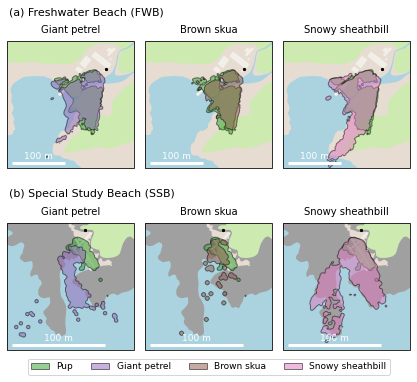

In [38]:

ALPHA = 1
prob = 99
sigma = 1
resolution = 1

bird_columns = ["giant petrel", "skua", "sheathbill"]

# Datasets you want to render (add as many as you like)
DATASETS = [
    {"name": "both_areas", "png": "map/both_areas.png", "kml": "map/both_areas.kml", "cdb": "both_areas_v1.cdb"},
    {"name": "SSB", "png": "map/SSB.png", "kml": "map/SSB.kml", "cdb": "map/SSB_v1.cdb"},
    {"name": "FWB", "png": "map/FWB.png", "kml": "map/FWB.kml", "cdb": "map/FWB_v1.cdb"},
]
row_configs = [
    (fwb, "Freshwater Beach (FWB)", "x_m", "y_m", cam_fwb, DATASETS[2]),
    (ssb, "Special Study Beach (SSB)", "x_m", "y_m", cam_ssb, DATASETS[1])
]

# Increased figsize height slightly to accommodate the new row titles
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(5.9, 6), 
                        subplot_kw={'projection': ccrs.Mercator()})

for row_idx, (df, loc_label, x_col, y_col, cam, ge_dataset) in enumerate(row_configs):
    
    target_col = 'class' if 'class' in df.columns else 'class_name'
    
    # Calculate PUP KDE once per row
    pts = df[df[target_col]=="pup"][[x_col,y_col]].dropna().values
    xpup, ypup = pts[:,0], pts[:,1]
    
    H, Hs, lines, rings, mp = kde_outline_from_hist2d_v2(
        xpup, ypup,
        prob=prob,
        resolution=resolution,
        sigma=sigma,
        return_shapely=True,
    )

    for col_idx, bird_class in enumerate(bird_columns):
        ax = axs[row_idx, col_idx]
        
        # 1. Base Map
        if loc_label == "Freshwater Beach (FWB)":
            plot_ge_dataset(ge_dataset, ax, ["background", "beach","water", "rocks","vegetation","stream","building","passway"])
        else:
            plot_ge_dataset(ge_dataset, ax, ["background", "water", "rocks","beach","vegetation","passway"])
        
        # Scalebar
        add_scalebar(ax, 100, label='100 m', location='lower left', color="white")
        
        # Plot PUP KDE (Filled Region)
        ax.add_geometries(multipolygon_to_gps(cam, mp), crs=ccrs.PlateCarree(),
                          facecolor=colors["pup"], edgecolor="k", alpha=0.5, zorder=5)
        
        ax.scatter(cam.gps_lon, cam.gps_lat, c="k", transform=ccrs.PlateCarree(), zorder=5, s=5)
    
        # Plot Bird KDE
        bird_df = df[df[target_col] == bird_class]
        pts_bird = bird_df[[x_col,y_col]].dropna().values
        if len(pts_bird) > 0:
            x, y = pts_bird[:,0], pts_bird[:,1]
            Hbird, Hsbird, linesbird, ringsbird, mpbird = kde_outline_from_hist2d_v2(
                x, y,
                prob=prob,
                resolution=resolution,
                sigma=sigma,
                return_shapely=True
            )
            ax.add_geometries(multipolygon_to_gps(cam, mpbird), crs=ccrs.PlateCarree(),
                              facecolor=colors[bird_class], edgecolor="k", alpha=0.5, zorder=5)
            
            print(loc_label,'A covered by B',bird_class,overlap_percent(mp,mpbird,mode="of_a"))
        
        # Set Class Title for EVERY subplot (both rows)
        label_text = labels.get(bird_class, bird_class)
        formatted_label = label_text[0].upper() + label_text[1:]
        ax.set_title(formatted_label, fontsize=10, pad=8)

    # Add Row Titles: (a) for row 0, (b) for row 1
    row_prefix = "(a)" if row_idx == 0 else "(b)"
    fig.text(0.03, 0.9 if row_idx == 0 else 0.48, f"{row_prefix} {loc_label}", 
             ha='left', va='center', fontsize=11)
    


# Build legend handles
legend_handles = []
legend_handles.append(
    patches.Patch(facecolor=colors["pup"], edgecolor="k", alpha=0.5, label=labels["pup"].capitalize())
)
for bird_class in bird_columns:
    label_text = labels[bird_class]
    formatted_label = label_text[0].upper() + label_text[1:]
    legend_handles.append(
        patches.Patch(facecolor=colors[bird_class], edgecolor="k", alpha=0.5, label=formatted_label)
    )

# Add legend below the subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles),
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.05),
)
# Adjust layout to make room for fig.text titles
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figures/figure5.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

### comparison to census data

In [39]:
ssb_census = pd.read_excel("assets/census_ssb.xlsx",sheet_name="Summary 20_21",skiprows=7)

Unknown extension is not supported and will be removed


In [40]:
import cameratransform as ct
import clickpoints
import numpy as np
from shapely.geometry import MultiPolygon, Polygon

# --- 1. Load camera ---
cam = ct.load_camera(ct_path)

# --- 2. Load passway polygons from cdb and project to space ---
polys_space = []

with clickpoints.DataFile(cdb_path, "r") as db:
    for poly in db.getPolygons(type="beach"):
        pts_px = np.array(poly.points)  # (N, 2) in pixel coords [x, y]
        
        # Project pixel → space (x_m, y_m, z_m) assuming Z=0 ground plane
        pts_space = cam.spaceFromImage(pts_px, Z=0)  # (N, 3)
        
        # Drop any NaN rows (points behind camera / outside FOV)
        valid = ~np.isnan(pts_space).any(axis=1)
        pts_space = pts_space[valid]
        
        if len(pts_space) >= 3:
            polys_space.append(Polygon(pts_space[:, :2]))  # use x_m, y_m only

# --- 3. Combine into a single MultiPolygon ---
beach_mp = MultiPolygon(polys_space)

print(f"Found {len(polys_space)} beach polygon(s)")
print(f"Total area: {passway_mp.area:.1f} m²")

Found 1 beach polygon(s)
Total area: 129.9 m²


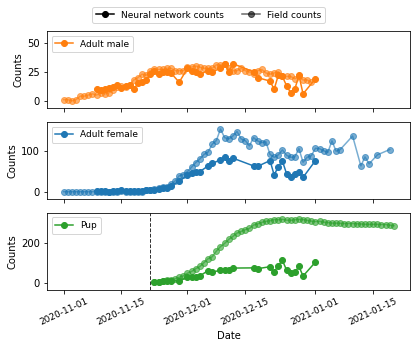

In [41]:
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.vectorized import contains

# --- Build rectangle polygon in space coords ---
rect_x0     = -3
rect_y0     = -6
rect_width  = 40
rect_height = -23
rect_angle  = -53

angle_rad = np.deg2rad(rect_angle)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

corners_local = np.array([
    [0,          0],
    [rect_width, 0],
    [rect_width, rect_height],
    [0,          rect_height],
])
corners_space = np.column_stack([
    rect_x0 + corners_local[:, 0] * cos_a - corners_local[:, 1] * sin_a,
    rect_y0 + corners_local[:, 0] * sin_a + corners_local[:, 1] * cos_a,
])
rect_poly_space = ShapelyPolygon(corners_space)

# --- Filter ---
valid_mask   = contains(rect_poly_space, ssb['x_m'].values, ssb['y_m'].values)
ssb_filtered = ssb[valid_mask].copy()

# --- Recompute abundance ---
ssb_abundance_filtered = daily_max_abundance(df=ssb_filtered)
ssb_abundance_filtered.index = pd.to_datetime(ssb_abundance_filtered.index)

# --- Plot (rest unchanged) ---
fig, ax = plt.subplots(nrows=3, figsize=(5.9, 5), sharex=True)

animal = "male"
ax[0].plot(ssb_abundance_filtered.index, ssb_abundance_filtered[animal],
           marker="o", color=colors[animal], label=labels[animal].capitalize())
male_census = ssb_census[["Date", "Territiorial male"]].dropna()
ax[0].plot(male_census["Date"], male_census["Territiorial male"],
           color=colors[animal], marker="o", alpha=0.6)
ax[0].legend(loc="upper left", fontsize=9)

animal = "female"
ax[1].plot(ssb_abundance_filtered.index, ssb_abundance_filtered[animal],
           marker="o", color=colors[animal], label=labels[animal].capitalize())
female_census = ssb_census[["Date", "Total # Females on beach in afternoon"]].dropna()
ax[1].plot(female_census["Date"], female_census["Total # Females on beach in afternoon"],
           color=colors[animal], marker="o", alpha=0.6)
ax[1].legend(loc="upper left", fontsize=9)

animal = "pup"
x_data_f = ssb_abundance_filtered.index
ax[2].plot(x_data_f[x_data_f > first_born_pup_ssb],
           ssb_abundance_filtered[animal][x_data_f > first_born_pup_ssb],
           marker="o", color=colors[animal], label=labels[animal].capitalize())
ssb_census["Total # Pups on beach"] = (ssb_census["Cumulative # pups"] - ssb_census["Cumulative Dead pups"])
pup_census = ssb_census[["Date", "Total # Pups on beach"]].dropna()
ax[2].plot(pup_census[pup_census.Date > first_born_pup_ssb]["Date"],
           pup_census[pup_census.Date > first_born_pup_ssb]["Total # Pups on beach"],
           color=colors[animal], marker="o", alpha=0.6)
ax[2].legend(loc="upper left", fontsize=9)

ax[0].set_ylim(-0.1 * 60,  60)
ax[1].set_ylim(-0.1 * 170, 170)
ax[2].set_ylim(-0.1 * 350, 350)
ax[2].axvline(first_born_pup_ssb, color='k', linestyle='--', linewidth=1, alpha=0.8, zorder=0)
ax[-1].tick_params(axis='x', rotation=25, labelsize=fontsize)

for a in ax:
    a.set_ylabel("Counts")
ax[-1].set_xlabel("Date")

nn_handle    = Line2D([0], [0], color='black', marker='o', linestyle='-', alpha=1.0, label='Neural network counts')
field_handle = Line2D([0], [0], color='black', marker='o', linestyle='-', alpha=0.6, label='Field counts')
fig.legend(handles=[nn_handle, field_handle],
           loc='lower center', bbox_to_anchor=(0.5, 0.9),
           ncols=2, fontsize=9, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("figures/SIfigure4_rect_filtered.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()

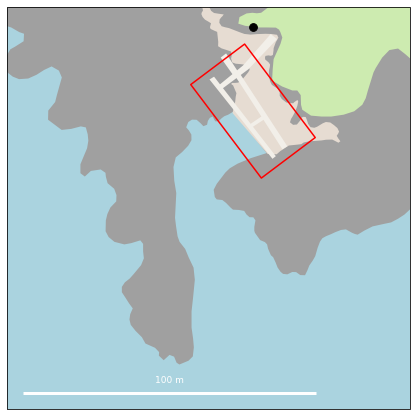

In [42]:
ge_dataset = DATASETS[1]  # SSB
img = plt.imread(ge_dataset["png"])
marker, fov, polys = read_cdb_layers(ge_dataset["cdb"], 
                                      wanted_layers=["background","water","rocks","beach","vegetation","passway"])
kml_corners = read_kml_corners(ge_dataset["kml"])
marker[["lon","lat"]] = kml_corners[["lon","lat"]].to_numpy()
pixel2ll = fit_pixel2lonlat(marker)

fig, ax = plt.subplots(figsize=(5.9, 5.9), subplot_kw={'projection': ccrs.Mercator()})
plot_ge_dataset(ge_dataset, ax, ["background","water","rocks","beach","vegetation","passway"])

# # --- Beach polygon in space coords → GPS ---
# beach_mp_gps = multipolygon_to_gps(cam_ssb, beach_mp)
# ax.add_geometries(beach_mp_gps, crs=ccrs.PlateCarree(), edgecolor="red", facecolor='none',
#                   alpha=1, lw=1.5, zorder=5)

# --- Camera position ---
ax.scatter(cam_ssb.gps_lon, cam_ssb.gps_lat, c="k", s=60, marker="o",
           transform=ccrs.PlateCarree(), zorder=6, label="Camera")

add_scalebar(ax, 100, label='100 m', location='lower left', color="white")

# --- Female detections: x_m, y_m → GPS ---
# animal = "male"
# animals = ssb[ssb["class"] == animal].dropna(subset=["x_m", "y_m"])
# pts_space = np.column_stack([animals["x_m"].values,
#                               animals["y_m"].values,
#                               np.zeros(len(animals))])
# gps = cam_ssb.gpsFromSpace(pts_space)
# ax.scatter(gps[:, 1], gps[:, 0],
#            c=colors[animal], s=0.1, alpha=0.7, zorder=10,
#            transform=ccrs.PlateCarree(), label=animal)



# --- Rectangle defined by start, width, height, angle → yellow polygon ---
rect_x0     = -3
rect_y0     = -6
rect_width  = 40
rect_height = -23
rect_angle  = -53

angle_rad = np.deg2rad(rect_angle)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

corners_local = np.array([
    [0,          0],
    [rect_width, 0],
    [rect_width, rect_height],
    [0,          rect_height],
])
corners_space = np.column_stack([
    rect_x0 + corners_local[:, 0] * cos_a - corners_local[:, 1] * sin_a,
    rect_y0 + corners_local[:, 0] * sin_a + corners_local[:, 1] * cos_a,
])
corners_3d  = np.column_stack([corners_space, np.zeros(len(corners_space))])
gps_corners = cam_ssb.gpsFromSpace(corners_3d)
rect_poly_ssb   = ShapelyPolygon(zip(gps_corners[:, 1], gps_corners[:, 0]))
ax.add_geometries([rect_poly_ssb], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red',
                  lw=1.5, zorder=12)

plt.tight_layout()
plt.savefig("figures/SIfigure6", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()